# 🌳 Unidad 4 — Clase 2: Binary Search Trees (BST)

## Información del Curso

| Aspecto | Detalle |
|--------|--------|
| **Universidad** | Universidad de Talca, Chile |
| **Carrera** | Ingeniería Civil en Informática |
| **Semestre** | 2°-3° año |
| **Curso** | Algoritmos y Estructuras de Datos |
| **Docente** | PhD. César Astudillo |
| **Clase** | Unidad 4, Clase 2 — Binary Search Trees |
| **Duración** | 90 minutos |

---
> 🎯 *Este notebook está diseñado para ser ejecutado en clase de forma interactiva.*  
> *Ejecuta las celdas en orden de arriba hacia abajo.*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from IPython.display import display, HTML
print("✅ Dependencias cargadas correctamente")

✅ Dependencias cargadas correctamente


## 🎯 Objetivos de Aprendizaje

Al finalizar esta sesión, el estudiante será capaz de:

1. **Definir** la propiedad BST y la estructura de un nodo (key, value, left, right, size).
2. **Implementar** `get` y `put` de forma recursiva sobre un BST.
3. **Implementar** operaciones de orden: `min`, `max`, `floor`, `ceiling`, `rank`, `select`.
4. **Analizar** la complejidad: O(log N) promedio vs O(N) peor caso.
5. **Comparar** BST con Sequential Search y Binary Search ST de la clase anterior.

---
# Sección 1: Motivación — El Problema Pendiente (10 minutos)

## ¿Dónde quedamos?

La clase pasada comparamos dos implementaciones de Symbol Table:

| Operación | Sequential Search | Binary Search ST |
|-----------|:-----------------:|:----------------:|
| `get` | O(N) | O(log N) ✅ |
| `put` | O(N) | O(N) ❌ |

Binary Search ST logró `get` en O(log N), pero `put` sigue siendo O(N) porque **desplazar elementos en un arreglo es caro**.

## La pregunta abierta

> ¿Podemos tener `get` **Y** `put` ambos en O(log N)?

La respuesta es sí — usando una estructura que **mantenga el orden sin necesitar desplazamientos**: el **Binary Search Tree**.

## La intuición

En lugar de un arreglo, usamos un árbol donde cada nodo conoce a sus dos hijos. Insertar un nuevo nodo es simplemente agregar una hoja — sin desplazar nada.

```
Arreglo ordenado:          BST equivalente:
                                   S
A C E G M P S Z                  / \
                                 E   Z
put('F') → desplazar        →   / \
A C E F G M P S Z              C   M
            ↑ O(N)            / \ / \
                             A  ? G  P
                                 ↑
                               O(log N)
```

> 🎙️ **[PAUSA PROFESOR]** *"¿Cómo sabemos dónde insertar en el árbol sin desplazar nada? ¿Qué propiedad nos guía?"*

---
# Sección 2: Definición del BST (15 minutos)

## La propiedad BST

Un **Binary Search Tree** es un árbol binario donde cada nodo tiene una clave, y se cumple para **todo** nodo:

> *Todas las claves en el subárbol **izquierdo** son **menores** que la clave del nodo.*  
> *Todas las claves en el subárbol **derecho** son **mayores** que la clave del nodo.*

```
        S
       / \
      E   X          Propiedad BST:
     / \             E < S < X
    A   R            A < E < R
     \               C < E
      C              R < S
```

## Estructura del nodo

Cada nodo almacena:
- `key` — la clave (comparable)
- `value` — el valor asociado
- `left` / `right` — referencias a los subárboles
- `size` — número de nodos en el subárbol enraizado aquí (útil para `rank` y `select`)

```python
class Node:
    def __init__(self, key, value):
        self.key   = key
        self.value = value
        self.left  = None
        self.right = None
        self.size  = 1    # contamos este nodo
```

## Tamaño del subárbol

El campo `size` cumple el invariante:  
`node.size = 1 + size(node.left) + size(node.right)`

Se mantiene actualizado en cada `put`. Se usa para implementar `rank` y `select` en O(log N).

> 🎙️ **[PAUSA PROFESOR]** *"¿Por qué guardar el tamaño en cada nodo en lugar de calcularlo dinámicamente cuando se necesite?"*  
> *Respuesta: calcularlo dinámicamente requeriría recorrer todo el subárbol — O(N). Guardarlo nos da O(1) con el costo de mantenerlo actualizado.*

In [2]:
class Node:
    """Nodo de un BST."""
    def __init__(self, key, value):
        self.key   = key
        self.value = value
        self.left  = None
        self.right = None
        self.size  = 1

    def __repr__(self):
        return f"Node({self.key}:{self.value}, size={self.size})"


def _size(node):
    """Tamaño del subárbol (None = 0)."""
    return 0 if node is None else node.size


# Función de visualización — usada en toda la clase
def mostrar_bst(root, titulo="BST"):
    """Muestra un BST como árbol de texto (estilo 'tree')."""
    print(f"\n{titulo}")
    if root is None:
        print("Árbol vacío")
        return
    print(f"{root.key} (sz={root.size})")
    _mostrar_hijos(root, "")


def _mostrar_hijos(node, prefix):
    hijos = [h for h in (node.left, node.right) if h is not None]
    for i, hijo in enumerate(hijos):
        last = (i == len(hijos) - 1)
        conector = "└── " if last else "├── "
        print(f"{prefix}{conector}{hijo.key} (sz={hijo.size})")
        extension = "    " if last else "│   "
        _mostrar_hijos(hijo, prefix + extension)

print("✅ Clase Node y función mostrar_bst definidas")

✅ Clase Node y función mostrar_bst definidas


---
# Sección 3: get y put (20 minutos)

## `get` — búsqueda

La propiedad BST nos dice exactamente hacia dónde ir en cada paso:

```
get('R') en el árbol:
         S
        / \
       E   X     → 'R' < 'S' → ir a la izquierda
      / \
     A   R       → 'R' > 'E' → ir a la derecha
          \
           ?     → 'R' == 'R' → ENCONTRADO ✓
```

**Pseudocódigo recursivo:**
```python
def get(node, key):
    if node is None:      return None          # no encontrado
    if key < node.key:    return get(node.left,  key)  # buscar izquierda
    if key > node.key:    return get(node.right, key)  # buscar derecha
    return node.value                           # encontrado
```

## `put` — inserción

Navegar igual que `get`, pero al llegar a `None` crear un nuevo nodo. El truco: la función **retorna el nodo** para que el padre pueda reconectar.

```
put('C', 4) en el árbol:
         S                    S
        / \                  / \
       E   X    →           E   X
      / \                  / \
     A   R                A   R
      \                    \
       None                 C    ← nuevo nodo
```

**Pseudocódigo recursivo:**
```python
def put(node, key, value):
    if node is None:      return Node(key, value)       # crear hoja
    if key < node.key:    node.left  = put(node.left,  key, value)
    elif key > node.key:  node.right = put(node.right, key, value)
    else:                 node.value = value            # actualizar
    node.size = 1 + _size(node.left) + _size(node.right)
    return node
```

> 🎙️ **[PAUSA PROFESOR]** *"¿Por qué `put` retorna el nodo en lugar de solo modificarlo? ¿Qué pasaría en el caso base (node is None) si no retornara nada?"*  
> *Respuesta: en el caso base creamos un nodo nuevo — el padre necesita recibir esa referencia para conectarla. El patrón 'retornar el nodo' es la forma elegante de manejar este caso.*

In [3]:
class BST:
    """
    Binary Search Tree — Symbol Table con árbol binario de búsqueda.
    Complejidad promedio: get O(log N), put O(log N).
    Complejidad peor caso: O(N) (árbol degenerado).
    """

    def __init__(self):
        self._root = None

    # ─── Tamaño ───────────────────────────────────────
    def size(self):
        return _size(self._root)

    def isEmpty(self):
        return self._root is None

    # ─── get ──────────────────────────────────────────
    def get(self, key):
        """Búsqueda — O(altura)."""
        if key is None:
            raise ValueError("key no puede ser None")
        return self._get(self._root, key)

    def _get(self, node, key):
        if node is None:        return None
        if key < node.key:      return self._get(node.left,  key)
        elif key > node.key:    return self._get(node.right, key)
        else:                   return node.value

    def contains(self, key):
        return self.get(key) is not None

    # ─── put ──────────────────────────────────────────
    def put(self, key, value):
        """Inserción o actualización — O(altura)."""
        if key is None:
            raise ValueError("key no puede ser None")
        self._root = self._put(self._root, key, value)

    def _put(self, node, key, value):
        if node is None:
            return Node(key, value)          # crear nueva hoja
        if key < node.key:
            node.left  = self._put(node.left,  key, value)
        elif key > node.key:
            node.right = self._put(node.right, key, value)
        else:
            node.value = value               # actualizar valor
        # Mantener invariante de tamaño
        node.size = 1 + _size(node.left) + _size(node.right)
        return node

    # ─── Recorrido en orden ───────────────────────────
    def keys(self):
        """Claves en orden (inorden del árbol)."""
        result = []
        self._inorden(self._root, result)
        return result

    def _inorden(self, node, result):
        if node is None:
            return
        self._inorden(node.left, result)
        result.append(node.key)
        self._inorden(node.right, result)

    def __repr__(self):
        return f"BST({self.keys()})"


# ── Demo ─────────────────────────────────────────────
bst = BST()
pares = [('S', 0), ('E', 1), ('A', 8), ('R', 3), ('C', 4),
         ('H', 5), ('E', 12), ('X', 7), ('M', 9)]

print("Insertando en orden:")
for k, v in pares:
    bst.put(k, v)
    print(f"  put('{k}', {v:2d})  →  size={bst.size()}  keys={bst.keys()}")

print(f"\nBúsquedas:")
for k in ['A', 'E', 'H', 'Z']:
    print(f"  get('{k}') = {bst.get(k)}")

mostrar_bst(bst._root, "BST tras insertar S E A R C H E X M")

Insertando en orden:
  put('S',  0)  →  size=1  keys=['S']
  put('E',  1)  →  size=2  keys=['E', 'S']
  put('A',  8)  →  size=3  keys=['A', 'E', 'S']
  put('R',  3)  →  size=4  keys=['A', 'E', 'R', 'S']
  put('C',  4)  →  size=5  keys=['A', 'C', 'E', 'R', 'S']
  put('H',  5)  →  size=6  keys=['A', 'C', 'E', 'H', 'R', 'S']
  put('E', 12)  →  size=6  keys=['A', 'C', 'E', 'H', 'R', 'S']
  put('X',  7)  →  size=7  keys=['A', 'C', 'E', 'H', 'R', 'S', 'X']
  put('M',  9)  →  size=8  keys=['A', 'C', 'E', 'H', 'M', 'R', 'S', 'X']

Búsquedas:
  get('A') = 8
  get('E') = 12
  get('H') = 5
  get('Z') = None

BST tras insertar S E A R C H E X M
S (sz=8)
├── E (sz=6)
│   ├── A (sz=2)
│   │   └── C (sz=1)
│   └── R (sz=3)
│       └── H (sz=2)
│           └── M (sz=1)
└── X (sz=1)


In [4]:
# Tracing visual de put paso a paso
def put_verbose(bst, key, value):
    """Versión pedagógica de put que muestra el camino recorrido."""
    print(f"put('{key}', {value}):")
    node = bst._root
    path = []
    while node is not None:
        path.append(node.key)
        if key < node.key:
            print(f"  '{key}' < '{node.key}' → ir a la izquierda")
            if node.left is None:
                print(f"  Izquierda vacía → crear Node('{key}', {value})")
                break
            node = node.left
        elif key > node.key:
            print(f"  '{key}' > '{node.key}' → ir a la derecha")
            if node.right is None:
                print(f"  Derecha vacía → crear Node('{key}', {value})")
                break
            node = node.right
        else:
            print(f"  '{key}' == '{node.key}' → actualizar value = {value}")
            break
    print(f"  Camino: {' → '.join(path)}")
    bst.put(key, value)
    print(f"  Árbol resultante (inorden): {bst.keys()}")
    print()

bst2 = BST()
for k, v in [('S', 0), ('E', 1), ('X', 7), ('A', 8), ('R', 3)]:
    bst2.put(k, v)

print("Estado inicial del BST (inorden):", bst2.keys())
mostrar_bst(bst2._root, "BST inicial")
print()
put_verbose(bst2, 'C', 4)
put_verbose(bst2, 'E', 99)
mostrar_bst(bst2._root, "BST tras put('C',4) y put('E',99)")

Estado inicial del BST (inorden): ['A', 'E', 'R', 'S', 'X']

BST inicial
S (sz=5)
├── E (sz=3)
│   ├── A (sz=1)
│   └── R (sz=1)
└── X (sz=1)

put('C', 4):
  'C' < 'S' → ir a la izquierda
  'C' < 'E' → ir a la izquierda
  'C' > 'A' → ir a la derecha
  Derecha vacía → crear Node('C', 4)
  Camino: S → E → A
  Árbol resultante (inorden): ['A', 'C', 'E', 'R', 'S', 'X']

put('E', 99):
  'E' < 'S' → ir a la izquierda
  'E' == 'E' → actualizar value = 99
  Camino: S → E
  Árbol resultante (inorden): ['A', 'C', 'E', 'R', 'S', 'X']


BST tras put('C',4) y put('E',99)
S (sz=6)
├── E (sz=4)
│   ├── A (sz=2)
│   │   └── C (sz=1)
│   └── R (sz=1)
└── X (sz=1)


---
# Sección 4: Operaciones de Orden (20 minutos)

## El inorden como clave

El recorrido **inorden** (izquierda → raíz → derecha) de un BST produce las claves **en orden ascendente**. Esta propiedad es la base de todas las operaciones de orden.

## min y max

```
min(): ir siempre a la izquierda hasta llegar a None
max(): ir siempre a la derecha hasta llegar a None

       S
      / \
     E   X   →  min = A (hoja más a la izquierda)
    / \          max = X (hoja más a la derecha)
   A   R
```

## floor y ceiling

`floor(key)`: mayor clave ≤ key.

```python
def floor(node, key):
    if node is None:       return None
    if key == node.key:    return node          # existe exactamente
    if key < node.key:     return floor(node.left, key)   # debe estar a la izq
    # key > node.key: este nodo es candidato; hay algo mayor a la derecha?
    t = floor(node.right, key)
    return t if t is not None else node
```

## rank y select

`rank(key)`: número de claves menores que key.  
Usa el campo `size` para evitar recorrer el árbol completo.

```python
def rank(node, key):
    if node is None:       return 0
    if key < node.key:     return rank(node.left, key)
    elif key > node.key:   return 1 + _size(node.left) + rank(node.right, key)
    else:                  return _size(node.left)      # nodo encontrado
```

`select(k)`: clave de rango k (la k-ésima más pequeña).

```python
def select(node, k):
    t = _size(node.left)
    if   t > k:  return select(node.left,  k)
    elif t < k:  return select(node.right, k - t - 1)
    else:        return node
```

> 🎙️ **[PAUSA PROFESOR]** *"¿Por qué `rank` en un BST puede ser O(log N) sin usar un arreglo ordenado? ¿Qué papel juega el campo `size`?"*  
> *Respuesta: gracias a `size`, sabemos cuántos nodos hay en cada subárbol sin recorrerlos. Esto permite calcular el rango saltándose subárboles enteros.*

In [5]:
class BST(BST):  # extender la clase anterior
    """
    BST con operaciones de orden completas.
    """

    # ─── min / max ────────────────────────────────────
    def min(self):
        if self.isEmpty(): raise IndexError("Árbol vacío")
        return self._min(self._root).key

    def _min(self, node):
        if node.left is None: return node
        return self._min(node.left)

    def max(self):
        if self.isEmpty(): raise IndexError("Árbol vacío")
        return self._max(self._root).key

    def _max(self, node):
        if node.right is None: return node
        return self._max(node.right)

    # ─── floor ────────────────────────────────────────
    def floor(self, key):
        """Mayor clave ≤ key — O(altura)."""
        node = self._floor(self._root, key)
        return None if node is None else node.key

    def _floor(self, node, key):
        if node is None:        return None
        if key == node.key:     return node           # existe exactamente
        if key < node.key:      return self._floor(node.left, key)
        # key > node.key: este nodo es candidato
        t = self._floor(node.right, key)
        return t if t is not None else node

    # ─── ceiling ──────────────────────────────────────
    def ceiling(self, key):
        """Menor clave ≥ key — O(altura)."""
        node = self._ceiling(self._root, key)
        return None if node is None else node.key

    def _ceiling(self, node, key):
        if node is None:        return None
        if key == node.key:     return node
        if key > node.key:      return self._ceiling(node.right, key)
        # key < node.key: este nodo es candidato
        t = self._ceiling(node.left, key)
        return t if t is not None else node

    # ─── rank ─────────────────────────────────────────
    def rank(self, key):
        """Número de claves menores que key — O(altura)."""
        return self._rank(self._root, key)

    def _rank(self, node, key):
        if node is None:        return 0
        if key < node.key:      return self._rank(node.left, key)
        elif key > node.key:    return 1 + _size(node.left) + self._rank(node.right, key)
        else:                   return _size(node.left)

    # ─── select ───────────────────────────────────────
    def select(self, k):
        """Clave de rango k (0-based) — O(altura)."""
        if k < 0 or k >= self.size():
            raise IndexError(f"rango {k} inválido")
        return self._select(self._root, k).key

    def _select(self, node, k):
        t = _size(node.left)
        if   t > k: return self._select(node.left,  k)
        elif t < k: return self._select(node.right, k - t - 1)
        else:       return node

    # ─── keys en rango ────────────────────────────────
    def keys_range(self, lo, hi):
        """Claves en [lo, hi] en orden."""
        result = []
        self._keys_range(self._root, lo, hi, result)
        return result

    def _keys_range(self, node, lo, hi, result):
        if node is None: return
        if lo < node.key:  self._keys_range(node.left,  lo, hi, result)
        if lo <= node.key <= hi: result.append(node.key)
        if hi > node.key:  self._keys_range(node.right, lo, hi, result)


# ── Demo con el horario de trenes ─────────────────────
horario = BST()
trenes = [
    ('08:30', 'Alameda'), ('06:10', 'Constitución'), ('10:00', 'Maipu'),
    ('07:45', 'Lo Espejo'), ('13:00', 'San Bernardo'), ('09:15', 'Pudahuel'),
    ('15:20', 'Buin'), ('11:30', 'Cerrillos'),
]
for hora, estacion in trenes:
    horario.put(hora, estacion)

print("Horario de trenes (BST, inorden):")
for hora in horario.keys():
    print(f"  {hora}  →  {horario.get(hora)}")

print()
print("Consultas con Ordered API sobre BST:")
print("-" * 50)
print(f"  min()              = {horario.min()}  → {horario.get(horario.min())}")
print(f"  max()              = {horario.max()}  → {horario.get(horario.max())}")
print(f"  floor('09:00')     = {horario.floor('09:00')}  → {horario.get(horario.floor('09:00'))}")
print(f"  ceiling('09:00')   = {horario.ceiling('09:00')}  → {horario.get(horario.ceiling('09:00'))}")
print(f"  rank('10:00')      = {horario.rank('10:00')}")
print(f"  select(3)          = {horario.select(3)}  → {horario.get(horario.select(3))}")
print(f"  keys_range(08-12)  = {horario.keys_range('08:00', '12:00')}")

mostrar_bst(horario._root, "BST del horario de trenes (insertado en orden no secuencial)")

Horario de trenes (BST, inorden):
  06:10  →  Constitución
  07:45  →  Lo Espejo
  08:30  →  Alameda
  09:15  →  Pudahuel
  10:00  →  Maipu
  11:30  →  Cerrillos
  13:00  →  San Bernardo
  15:20  →  Buin

Consultas con Ordered API sobre BST:
--------------------------------------------------
  min()              = 06:10  → Constitución
  max()              = 15:20  → Buin
  floor('09:00')     = 08:30  → Alameda
  ceiling('09:00')   = 09:15  → Pudahuel
  rank('10:00')      = 4
  select(3)          = 09:15  → Pudahuel
  keys_range(08-12)  = ['08:30', '09:15', '10:00', '11:30']

BST del horario de trenes (insertado en orden no secuencial)
08:30 (sz=8)
├── 06:10 (sz=2)
│   └── 07:45 (sz=1)
└── 10:00 (sz=5)
    ├── 09:15 (sz=1)
    └── 13:00 (sz=3)
        ├── 11:30 (sz=1)
        └── 15:20 (sz=1)


---
# Sección 5: Análisis de Complejidad (15 minutos)

## La altura del árbol es todo

Todas las operaciones del BST dependen de la **altura del árbol** (número de niveles).

La pregunta clave: ¿cuánto vale la altura?

## Caso promedio — inserción aleatoria

Si las N claves se insertan en **orden aleatorio**, la altura esperada es ~**2 ln N** ≈ 1.39 log₂ N.

```
Para N = 1.000.000:  altura ≈ 2 × ln(1.000.000) ≈ 28
```

Esto da O(log N) para get, put y todas las operaciones de orden.

## Peor caso — inserción ordenada

Si las claves se insertan **en orden ascendente o descendente**, el árbol **degenera** en una lista enlazada:

```
put(1), put(2), put(3), put(4), put(5):

  1
   \
    2
     \
      3        ← altura = N → O(N)
       \
        4
         \
          5
```

Altura = N → todas las operaciones son O(N). ¡Peor que Binary Search ST!

## Comparación final

| Implementación | get | put | min/max | floor/ceil | Peor caso |
|---------------|-----|-----|---------|-----------|----------|
| Sequential Search | O(N) | O(N) | O(N) | — | Siempre |
| Binary Search ST | O(log N) | O(N) | O(1) | O(log N) | Siempre |
| **BST** | **O(log N)** | **O(log N)** | **O(log N)** | **O(log N)** | O(N) si ordenado |

> 🎙️ **[PREGUNTA DE CIERRE]** *"El BST es excelente en promedio pero tiene peor caso O(N). ¿Cómo podríamos garantizar O(log N) siempre, incluso con inserción ordenada?"*  
> *Respuesta en próximas clases: árboles balanceados (Red-Black Trees, AVL), que se re-balancean automáticamente.*

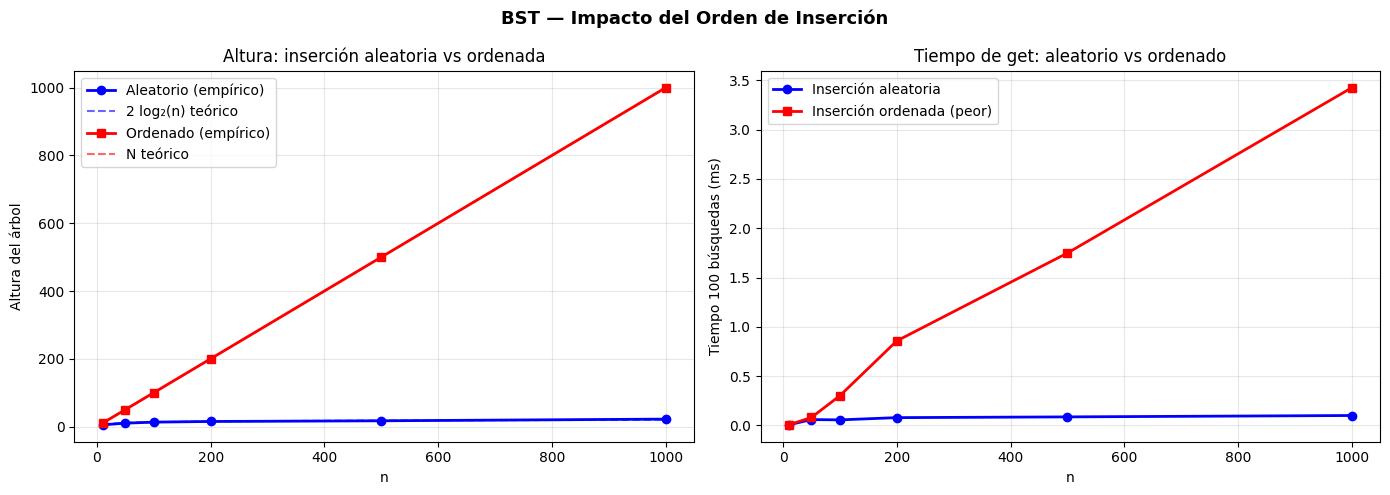

     n    Altura rand     2log₂n   Altura sorted      N
-------------------------------------------------------
    10              5        6.6              10     10
    50             10       11.3              50     50
   100             13       13.3             100    100
   200             15       15.3             200    200
   500             17       17.9             500    500
  1000             22       19.9            1000   1000


In [6]:
# Visualización: árbol aleatorio vs árbol degenerado
def altura_bst(root):
    if root is None: return 0
    return 1 + max(altura_bst(root.left), altura_bst(root.right))

ns = [10, 50, 100, 200, 500, 1000]
alturas_random = []
alturas_sorted = []

for n in ns:
    # Inserción aleatoria
    claves = random.sample(range(n * 10), n)
    bst_rand = BST()
    for k in claves: bst_rand.put(k, k)
    alturas_random.append(altura_bst(bst_rand._root))

    # Inserción ordenada (peor caso)
    bst_sorted = BST()
    for k in sorted(claves): bst_sorted.put(k, k)
    alturas_sorted.append(altura_bst(bst_sorted._root))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

teorico_log  = [2 * np.log2(n) for n in ns]
teorico_n    = ns

axes[0].plot(ns, alturas_random, 'bo-', label='Aleatorio (empírico)', linewidth=2)
axes[0].plot(ns, teorico_log,   'b--', label='2 log₂(n) teórico', alpha=0.6)
axes[0].plot(ns, alturas_sorted, 'rs-', label='Ordenado (empírico)', linewidth=2)
axes[0].plot(ns, teorico_n,     'r--', label='N teórico', alpha=0.6)
axes[0].set_xlabel('n'); axes[0].set_ylabel('Altura del árbol')
axes[0].set_title('Altura: inserción aleatoria vs ordenada')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Comparar tiempo de get
tiempos_rand = []; tiempos_sort = []
for i, n in enumerate(ns):
    claves = random.sample(range(n * 10), n)
    bst_r = BST()
    for k in claves: bst_r.put(k, k)
    bst_s = BST()
    for k in sorted(claves): bst_s.put(k, k)

    muestra = random.sample(claves, min(100, n))
    t0 = time.perf_counter()
    for k in muestra: bst_r.get(k)
    tiempos_rand.append((time.perf_counter()-t0)*1000)

    t0 = time.perf_counter()
    for k in muestra: bst_s.get(k)
    tiempos_sort.append((time.perf_counter()-t0)*1000)

axes[1].plot(ns, tiempos_rand, 'bo-', label='Inserción aleatoria', linewidth=2)
axes[1].plot(ns, tiempos_sort, 'rs-', label='Inserción ordenada (peor)', linewidth=2)
axes[1].set_xlabel('n'); axes[1].set_ylabel('Tiempo 100 búsquedas (ms)')
axes[1].set_title('Tiempo de get: aleatorio vs ordenado')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('BST — Impacto del Orden de Inserción', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'n':>6} {'Altura rand':>14} {'2log₂n':>10} {'Altura sorted':>15} {'N':>6}")
print("-" * 55)
for i, n in enumerate(ns):
    print(f"{n:>6} {alturas_random[i]:>14} {2*np.log2(n):>10.1f} {alturas_sorted[i]:>15} {n:>6}")

---
# Sección 6: Resumen (5 minutos)

## Lo que aprendimos hoy

| Concepto | Descripción |
|---------|-------------|
| **Propiedad BST** | Todo nodo: izquierda < nodo < derecha |
| **Nodo** | key, value, left, right, size |
| **get** | Seguir la propiedad BST hasta encontrar o llegar a None — O(altura) |
| **put** | Igual que get, crear hoja al llegar a None, retornar nodo — O(altura) |
| **Inorden** | Recorre el BST produciendo las claves en orden ascendente |
| **floor/ceiling** | Navegación recursiva; el nodo actual es candidato al cruzar |
| **rank/select** | Usan el campo `size` para saltar subárboles enteros — O(altura) |
| **Complejidad** | Promedio O(log N) con inserción aleatoria; O(N) si insertamos en orden |

## El problema que queda

BST resuelve el problema de `put` O(N), pero introduce el peor caso O(N) por árbol degenerado.  
La próxima clase veremos cómo garantizar O(log N) **siempre** con árboles autobalanceados.

---
## Referencias

- Sedgewick & Wayne. *Algorithms*, 4ª ed., Sección 3.2 — Binary Search Trees
- Cormen et al. *Introduction to Algorithms* (CLRS), Cap. 12